Experiment 1(a):Single-Layer Perceptron Implementation for AND Gate Classification

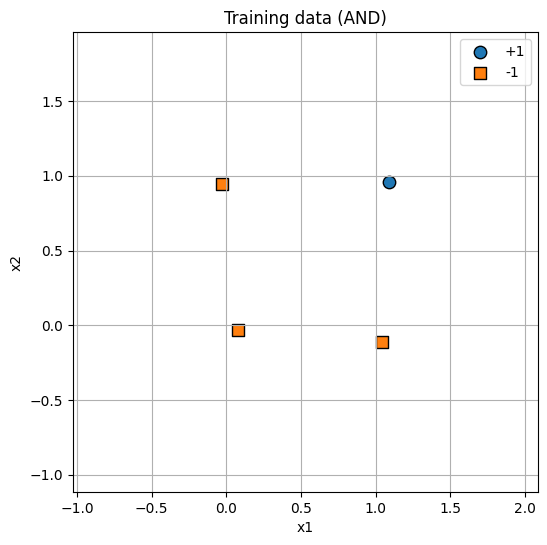

Weights (bias, w1, w2): [-0.28375655  0.21180372  0.12472162]
Training accuracy: 1.0


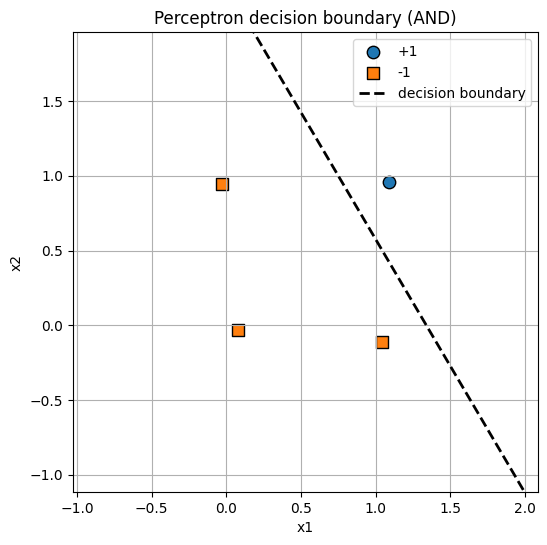

Saved plot to perceptron_and.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# NOTE (Jupyter only): Uncomment the next line if running in a notebook
# %matplotlib inline


def plot_data(X, y, w=None, title="", save_path=None):
    """
    Plot 2D data points and (optionally) the perceptron decision boundary.

    Parameters
    ----------
    X : np.ndarray of shape (n_samples, 2)
        Input features (2D).
    y : np.ndarray of shape (n_samples,)
        Labels must be +1 or -1.
    w : np.ndarray of shape (3,), optional
        Weight vector including bias as w[0] (i.e., [b, w1, w2]).
    title : str
        Plot title.
    save_path : str or None
        If provided, saves the figure to this path.
    """
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)

    plt.figure(figsize=(6, 6))

    # Scatter plot: separate +1 and -1
    pos = (y == 1)
    neg = (y == -1)
    plt.scatter(X[pos, 0], X[pos, 1], marker="o", label="+1", edgecolor="k", s=80)
    plt.scatter(X[neg, 0], X[neg, 1], marker="s", label="-1", edgecolor="k", s=80)

    # Plot decision boundary if weights are provided
    if w is not None:
        w = np.asarray(w, dtype=float).ravel()
        if w.shape[0] != 3:
            raise ValueError("w must have length 3: [bias, w1, w2]")

        b, w1, w2 = w[0], w[1], w[2]
        xs = np.array([X[:, 0].min() - 1, X[:, 0].max() + 1], dtype=float)

        # Decision boundary: b + w1*x1 + w2*x2 = 0  =>  x2 = -(b + w1*x1)/w2
        if abs(w2) > 1e-9:
            ys = -(b + w1 * xs) / w2
            plt.plot(xs, ys, "k--", linewidth=2, label="decision boundary")
        else:
            # If w2 is ~0, boundary is vertical: b + w1*x1 = 0 => x1 = -b/w1
            if abs(w1) > 1e-9:
                x_vertical = -b / w1
                plt.axvline(x=x_vertical, linestyle="--", linewidth=2, label="decision boundary")
            # else: w1 and w2 both 0 -> no meaningful boundary

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.xlim(X[:, 0].min() - 1, X[:, 0].max() + 1)
    plt.ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)
    plt.gca().set_aspect("equal", adjustable="box")

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()


class Perceptron:
    """
    Single-layer perceptron classifier for labels in {-1, +1}.

    Learning rule (classic):
      if misclassified: w <- w + lr * y_i * x_i
    Bias is included by augmenting x with a leading 1.
    """

    def __init__(self, lr=0.1, n_iters=1000, random_state=1):
        self.lr = float(lr)
        self.n_iters = int(n_iters)
        self.rng = np.random.RandomState(random_state)
        self.w = None  # includes bias as w[0]

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)

        # Basic checks
        if X.ndim != 2:
            raise ValueError("X must be a 2D array of shape (n_samples, n_features)")
        if y.ndim != 1:
            raise ValueError("y must be a 1D array of shape (n_samples,)")
        if X.shape[0] != y.shape[0]:
            raise ValueError("X and y must have the same number of samples")
        if not np.all(np.isin(y, [-1, 1])):
            raise ValueError("Perceptron expects labels to be -1 or +1")

        n_samples, n_features = X.shape

        # Add bias term: X_aug = [1, x1, x2, ...]
        X_aug = np.hstack([np.ones((n_samples, 1)), X])

        # Initialize small random weights (bias + feature weights)
        self.w = self.rng.normal(scale=0.01, size=(n_features + 1,))

        # Training loop
        for epoch in range(self.n_iters):
            errors = 0

            for xi, yi in zip(X_aug, y):
                activation = np.dot(self.w, xi)
                y_pred = 1 if activation >= 0 else -1

                # Update only when misclassified
                if y_pred != yi:
                    self.w += self.lr * yi * xi
                    errors += 1

            # Stop early if perfect classification is achieved
            if errors == 0:
                # print(f"Converged at epoch {epoch}")
                break

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        X_aug = np.hstack([np.ones((X.shape[0], 1)), X])
        activations = X_aug.dot(self.w)
        return np.where(activations >= 0, 1, -1)

    def score(self, X, y):
        """Accuracy score."""
        y = np.asarray(y)
        preds = self.predict(X)
        return np.mean(preds == y)


# -----------------------------
# Demo dataset: AND gate (as +/-1)
# -----------------------------
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]], dtype=float)

y = np.array([-1, -1, -1, 1])  # AND -> +1 only for (1,1)

# Optional: add small jitter to visualize points better (still separable)
rng = np.random.RandomState(1)
X_jitter = X + 0.05 * rng.randn(*X.shape)

plot_data(X_jitter, y, title="Training data (AND)")

# Train perceptron
perc = Perceptron(lr=0.1, n_iters=100)
perc.fit(X_jitter, y)

print("Weights (bias, w1, w2):", perc.w)
print("Training accuracy:", perc.score(X_jitter, y))

# Plot and save decision boundary
plot_data(
    X_jitter,
    y,
    w=perc.w,
    title="Perceptron decision boundary (AND)",
    save_path="perceptron_and.png"   # change path as needed
)

print("Saved plot to perceptron_and.png")


Experiment 1(b): Implementation of a Multi-Layer Perceptron for Solving XOR Classification

In [1]:
pip install tensorflow

TensorFlow version: 2.19.0


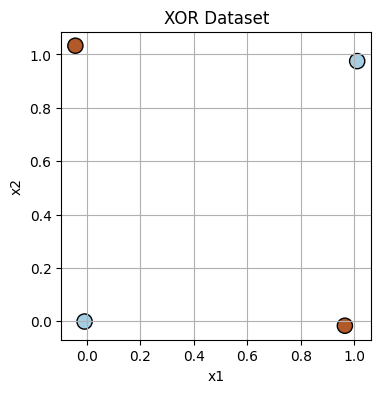

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

Final loss: 0.0006, accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Raw predictions (probabilities):
[6.5447635e-04 9.9931508e-01 9.9952358e-01 4.3647247e-04]
Rounded predictions (0/1):
[0 1 1 0]
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


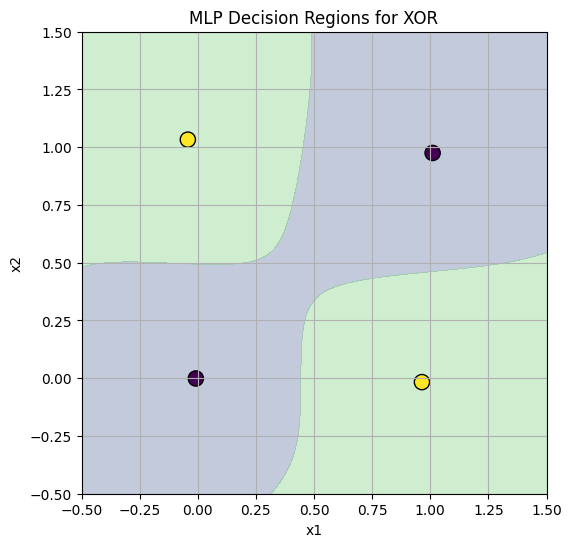

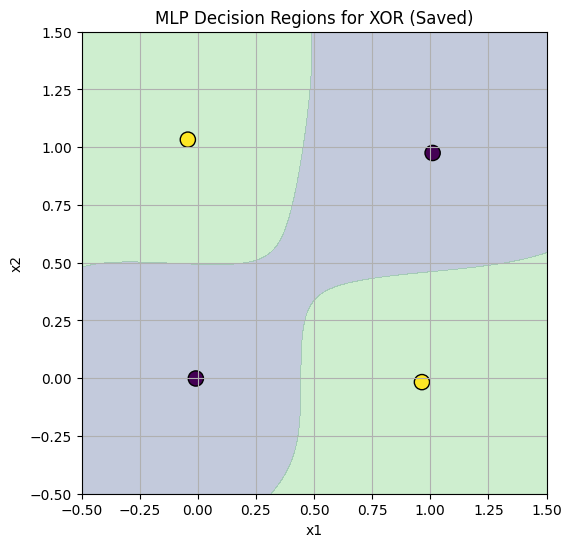

Saved XOR decision plot to mlp_xor_decision.png


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

# NOTE (Jupyter only): Uncomment if running in a notebook
# %matplotlib inline

print("TensorFlow version:", tf.__version__)


# -----------------------------
# Prepare XOR Dataset
# -----------------------------
# XOR truth table inputs
X_xor = np.array([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]], dtype=float)

# XOR outputs (0/1 for sigmoid + binary_crossentropy)
y_xor = np.array([[0],
                  [1],
                  [1],
                  [0]], dtype=float)

# Optional: small noise for better visualization (still XOR)
rng = np.random.RandomState(2)
X_xor = X_xor + 0.02 * rng.randn(*X_xor.shape)

# Plot XOR data
plt.figure(figsize=(4, 4))
plt.scatter(
    X_xor[:, 0],
    X_xor[:, 1],
    c=y_xor.flatten(),
    cmap=plt.cm.Paired,
    s=120,
    edgecolor='k'
)
plt.title('XOR Dataset')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)
plt.show()


# -----------------------------
# Build MLP Model
# -----------------------------
# One hidden layer with non-linear activation
model = Sequential([
    Input(shape=(2,)),                       # Explicit input layer (best practice)
    Dense(4, activation='tanh', name='hidden_layer'),
    Dense(1, activation='sigmoid', name='output_layer')
])

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.05),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


# -----------------------------
# Train the Model
# -----------------------------
history = model.fit(
    X_xor,
    y_xor,
    epochs=500,
    batch_size=4,
    verbose=0
)

# Evaluate performance
loss, acc = model.evaluate(X_xor, y_xor, verbose=0)
print(f"Final loss: {loss:.4f}, accuracy: {acc:.4f}")


# -----------------------------
# Predictions
# -----------------------------
preds = model.predict(X_xor)

print("Raw predictions (probabilities):")
print(preds.flatten())

print("Rounded predictions (0/1):")
print((preds >= 0.5).astype(int).flatten())


# -----------------------------
# Decision Boundary Visualization
# -----------------------------
xx = np.linspace(-0.5, 1.5, 200)
yy = np.linspace(-0.5, 1.5, 200)
XX, YY = np.meshgrid(xx, yy)

grid = np.c_[XX.ravel(), YY.ravel()]
Z = model.predict(grid).reshape(XX.shape)

plt.figure(figsize=(6, 6))
plt.contourf(XX, YY, Z, levels=[-0.01, 0.5, 1.01], alpha=0.3)
plt.scatter(
    X_xor[:, 0],
    X_xor[:, 1],
    c=y_xor.flatten(),
    edgecolor='k',
    s=120
)
plt.title('MLP Decision Regions for XOR')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)
plt.show()


# -----------------------------
# Save Plot
# -----------------------------
plt.figure(figsize=(6, 6))
plt.contourf(XX, YY, Z, levels=[-0.01, 0.5, 1.01], alpha=0.3)
plt.scatter(
    X_xor[:, 0],
    X_xor[:, 1],
    c=y_xor.flatten(),
    edgecolor='k',
    s=120
)
plt.title('MLP Decision Regions for XOR (Saved)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)
plt.savefig('mlp_xor_decision.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved XOR decision plot to mlp_xor_decision.png")


Conclusion:
The single-layer perceptron successfully classified the linearly separable AND dataset, while the MLP with a hidden layer accurately learned the XOR problem, demonstrating the necessity of multi-layer networks for solving non-linear classification tasks.
